# fio DFS Heatmap Sweep — iodepth × block size

Analyzes results from a single-job sweep of `(iodepth, block_size)` pairs with the DAOS DFS ioengine.  
Produces heatmaps of **throughput (BW, IOPS)** and **latency** as functions of both dimensions.

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path(".")

BS_ORDER   = ["4k", "16k", "1m", "2m", "4m"]
IOD_ORDER  = [4, 8, 16, 32, 64, 128, 256]

In [2]:
def bs_to_bytes(bs: str) -> int:
    bs = bs.lower()
    if bs.endswith("k"):
        return int(bs[:-1]) * 1024
    if bs.endswith("m"):
        return int(bs[:-1]) * 1024 ** 2
    return int(bs)

def parse_file(fpath: Path) -> dict:
    m = re.search(r"fio_\w+_bs(\w+?)_nj(\d+)_iod(\d+)_", fpath.name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))

    with open(fpath) as f:
        d = json.load(f)

    job = d["jobs"][0]
    # pick the active direction (read or write)
    io = job["read"] if job["read"]["io_bytes"] > 0 else job["write"]
    clat = io["clat_ns"]
    lat  = io["lat_ns"]
    cp   = clat["percentile"]

    def ms(v): return v / 1e6

    return dict(
        bs             = bs,
        iodepth        = iod,
        numjobs        = nj,
        bw_GiBs        = io["bw_bytes"] / 1024**3,
        iops           = io["iops"],
        lat_min_ms     = ms(lat["min"]),
        lat_mean_ms    = ms(lat["mean"]),
        lat_max_ms     = ms(lat["max"]),
        clat_mean_ms   = ms(clat["mean"]),
        clat_p50_ms    = ms(cp["50.000000"]),
        clat_p90_ms    = ms(cp["90.000000"]),
        clat_p99_ms    = ms(cp["99.000000"]),
        clat_p99_9_ms  = ms(cp["99.900000"]),
        clat_p99_99_ms = ms(cp["99.990000"]),
    )

files = sorted(RESULTS_DIR.glob("fio_seq_read_*.json"))
df = pd.DataFrame([parse_file(f) for f in files])

df["bs_bytes"] = df["bs"].apply(bs_to_bytes)
df["bs"]       = pd.Categorical(df["bs"],      categories=BS_ORDER,  ordered=True)
df["iodepth"]  = pd.Categorical(df["iodepth"], categories=IOD_ORDER, ordered=True)
df = df.sort_values(["bs_bytes", "iodepth"]).reset_index(drop=True)

print(f"Loaded {len(df)} seq_read result files")
df

Loaded 35 seq_read result files


,bs,iodepth,numjobs,bw_GiBs,iops,lat_min_ms,lat_mean_ms,lat_max_ms,clat_mean_ms,clat_p50_ms,clat_p90_ms,clat_p99_ms,clat_p99_9_ms,clat_p99_99_ms,bs_bytes
0,4k,4,1,0.099213,26008.066532,0.083451,0.153463,12.925588,0.149381,0.136192,0.220160,0.232448,0.264192,8.716288,4096
1,4k,8,1,0.141088,36985.483575,0.032731,0.215977,12.941608,0.211776,0.201728,0.301056,0.354304,0.452608,9.764864,4096
2,4k,16,1,0.175591,46030.182830,0.034671,0.347251,14.526919,0.343246,0.358400,0.497664,0.593920,0.880640,10.158080,4096
3,4k,32,1,0.271342,71130.764487,0.085012,0.449502,16.611911,0.445219,0.419840,0.724992,0.864256,1.171456,11.337728,4096
4,4k,64,1,0.305579,80105.729809,0.088992,0.798557,13.671313,0.795914,0.790528,1.122304,1.236992,5.668864,11.730944,4096
5,4k,128,1,0.399531,104734.725509,0.406218,1.221705,29.972118,1.219449,1.204224,1.548288,1.695744,8.355840,13.303808,4096
6,4k,256,1,0.389781,102178.657734,1.763775,2.504612,16.723402,2.502368,2.473984,2.801664,3.031040,12.517376,15.138816,4096
7,16k,4,1,0.246915,16181.830303,0.135972,0.246792,12.977779,0.241115,0.236544,0.288768,0.325632,0.399360,9.240576,16384
8,16k,8,1,0.433686,28422.042966,0.146113,0.281078,13.281739,0.275519,0.264192,0.358400,0.423936,0.493568,10.289152,16384
9,16k,16,1,0.820782,53790.736821,0.133543,0.297065,13.388545,0.291948,0.288768,0.362496,0.419840,0.569344,9.502720,16384


## Seqread Bandwidth/IOPS/Lat_mean Heatmaps

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_12603/3470385978.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = p.applymap(lambda v: ann_fn(v) if pd.notna(v) else "")


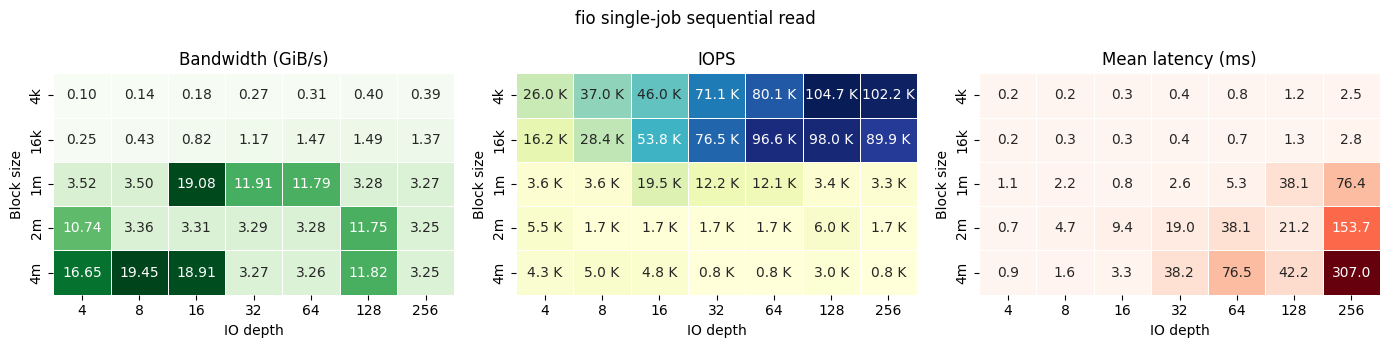

In [ ]:
def pivot(metric):
    return df.pivot(index="bs", columns="iodepth", values=metric).loc[BS_ORDER, IOD_ORDER]

def make_annot(p, fmt, ann_fn=None):
    if ann_fn is None:
        return True, fmt
    annot = p.applymap(lambda v: ann_fn(v) if pd.notna(v) else "")
    return annot, ""

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

specs = [
    ("bw_GiBs",    "Bandwidth (GiB/s)", ".2f", "Greens", None),
    ("iops",       "IOPS",              ".0f", "YlGnBu", lambda v: f"{v/1e3:.1f} K"),
    ("lat_mean_ms","Mean latency (ms)", ".1f", "Reds",  None),
]
for ax, (metric, label, fmt, cmap, ann_fn) in zip(axes, specs):
    p = pivot(metric)
    annot, efmt = make_annot(p, fmt, ann_fn)
    sns.heatmap(
        p, ax=ax, cmap=cmap, annot=annot, fmt=efmt,
        linewidths=0.5, cbar=False
    )
    ax.set_title(label)
    ax.set_xlabel("IO depth")
    ax.set_ylabel("Block size")
    ax.tick_params(axis="x", rotation=0)
    fig.suptitle("fio single-job sequential read")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_seqread_iod-bs.pdf", bbox_inches="tight", dpi=150)
plt.show()

## Latency Heatmaps

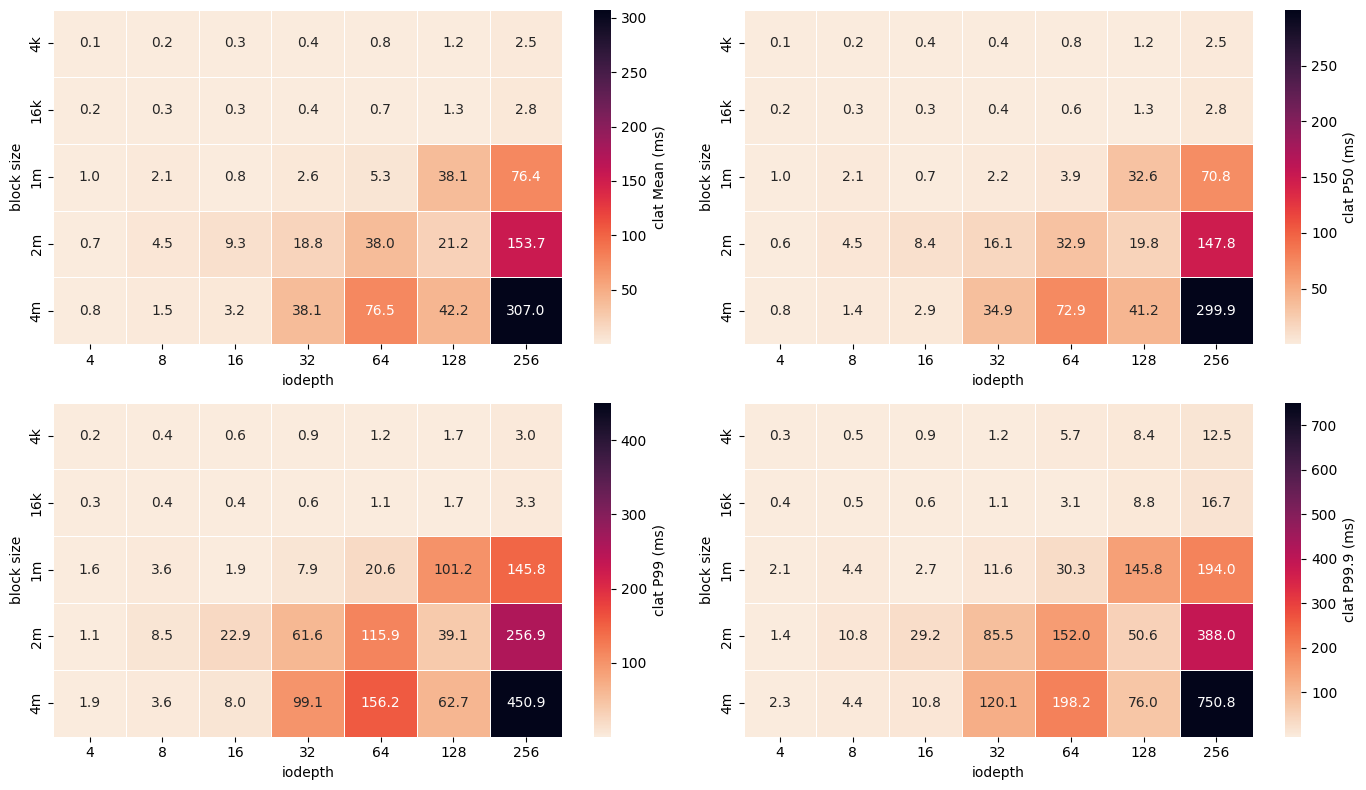

In [4]:
lat_metrics = [
    ("clat_mean_ms",   "clat Mean (ms)"),
    ("clat_p50_ms",    "clat P50 (ms)"),
    ("clat_p99_ms",    "clat P99 (ms)"),
    ("clat_p99_9_ms",  "clat P99.9 (ms)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (metric, label) in zip(axes.flat, lat_metrics):
    p = pivot(metric)
    sns.heatmap(
        p, ax=ax, cmap="rocket_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_xlabel("iodepth")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_latency.pdf", bbox_inches="tight", dpi=150)
plt.show()

## Tail Latency Detail — P99 & P99.9

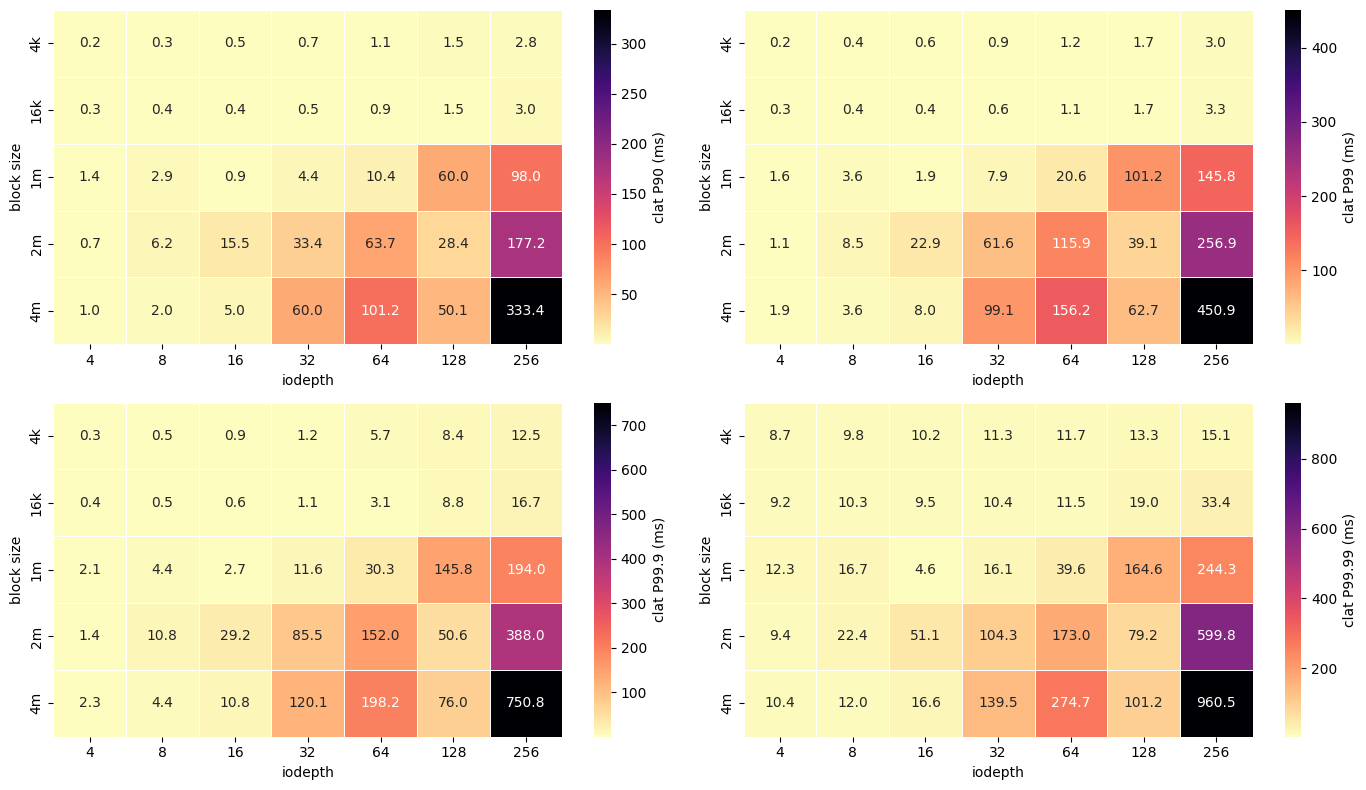

In [5]:
tail_metrics = [
    ("clat_p90_ms",    "clat P90 (ms)"),
    ("clat_p99_ms",    "clat P99 (ms)"),
    ("clat_p99_9_ms",  "clat P99.9 (ms)"),
    ("clat_p99_99_ms", "clat P99.99 (ms)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (metric, label) in zip(axes.flat, tail_metrics):
    p = pivot(metric)
    sns.heatmap(
        p, ax=ax, cmap="magma_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_xlabel("iodepth")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_tail_latency.pdf", bbox_inches="tight", dpi=150)
plt.show()

## Total Latency — Min / Mean / Max

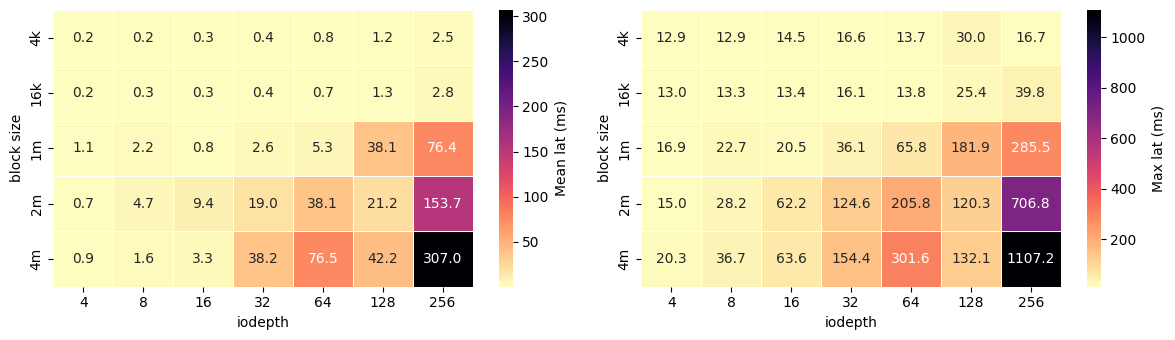

In [6]:
minmeanmax_metrics = [
    # ("lat_min_ms",  "Min lat (ms)"),
    ("lat_mean_ms", "Mean lat (ms)"),
    ("lat_max_ms",  "Max lat (ms)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for ax, (metric, label) in zip(axes, minmeanmax_metrics):
    p = pivot(metric)
    sns.heatmap(
        p, ax=ax, cmap="magma_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_xlabel("iodepth")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_lat_mean_max.pdf", bbox_inches="tight", dpi=150)
plt.show()

## rand_write — Bandwidth, IOPS, Mean Latency

Loaded 35 rand_write result files


/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_12603/3470385978.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = p.applymap(lambda v: ann_fn(v) if pd.notna(v) else "")


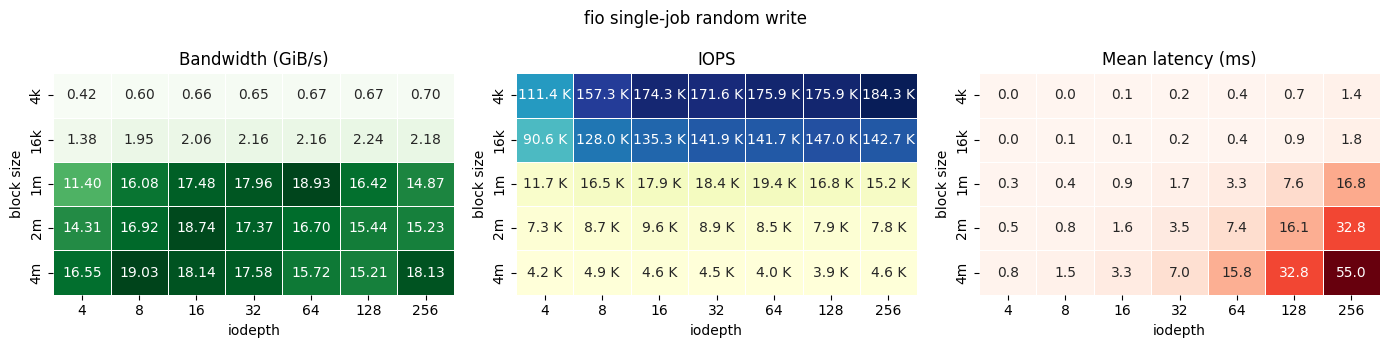

In [ ]:
rw_files = sorted(RESULTS_DIR.glob("fio_rand_write_*.json"))
df_rw = pd.DataFrame([parse_file(f) for f in rw_files])
df_rw["bs_bytes"] = df_rw["bs"].apply(bs_to_bytes)
df_rw["bs"]       = pd.Categorical(df_rw["bs"],      categories=BS_ORDER,  ordered=True)
df_rw["iodepth"]  = pd.Categorical(df_rw["iodepth"], categories=IOD_ORDER, ordered=True)
df_rw = df_rw.sort_values(["bs_bytes", "iodepth"]).reset_index(drop=True)

print(f"Loaded {len(df_rw)} rand_write result files")

def pivot_rw(metric):
    return df_rw.pivot(index="bs", columns="iodepth", values=metric).reindex(
        index=BS_ORDER, columns=IOD_ORDER
    )

rw_specs = [
    ("bw_GiBs",      "Bandwidth (GiB/s)", ".2f", "Greens", None),
    ("iops",         "IOPS",              ".0f", "YlGnBu", lambda v: f"{v/1e3:.1f} K"),
    ("clat_mean_ms", "Mean latency (ms)", ".1f", "Reds",  None),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, (metric, label, fmt, cmap, ann_fn) in zip(axes, rw_specs):
    p = pivot_rw(metric)
    annot, efmt = make_annot(p, fmt, ann_fn)
    sns.heatmap(
        p, ax=ax, cmap=cmap, annot=annot, fmt=efmt,
        linewidths=0.5, cbar=False
    )
    ax.set_title(label)
    ax.set_xlabel("iodepth")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)
    fig.suptitle("fio single-job random write")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_randwrite_iod-bs.pdf", bbox_inches="tight", dpi=150)
plt.show()

## Findings & Conclusion

**Workloads:** `seq_read` and `rand_write`, single job (`numjobs=1`), DAOS DFS ioengine, 60 s per run.  
Axes: block size ∈ {4k, 16k, 1m, 2m, 4m} × iodepth ∈ {4, 8, 16, 32, 64, 128, 256}.

---

### Finding 1 — seq_read: large-block BW collapses to discrete regimes; rand_write does not

For `seq_read` with large blocks (1m–4m), bandwidth is non-monotonic and jumps between three discrete levels depending on iodepth:

| Regime | BW | Example seq_read configs |
|--------|----|--------------------------|
| Floor | ~3.3 GiB/s | 1m iod≤8 or ≥128 · 2m iod=8–64 or 256 · 4m iod≥32 (except 128) |
| Intermediate | ~11.8 GiB/s | 1m iod=32,64 · 2m iod=4,128 · 4m iod=128 |
| Peak | ~16.7–19.5 GiB/s | 1m iod=16 · 4m iod=4,8,16 |

For `rand_write`, **this collapse does not occur**. Large-block BW stays consistently high across the entire iodepth range:

| Block size | rand_write BW range (GiB/s) | seq_read BW range (GiB/s) |
|------------|-----------------------------|---------------------------|
| 1m | 11.4 – 18.9 (1.7× spread) | 3.3 – 19.1 (5.8× spread) |
| 2m | 14.3 – 18.7 (1.3× spread) | 3.2 – 10.7 (3.3× spread) |
| 4m | 15.2 – 19.0 (1.3× spread) | 3.3 – 19.5 (5.9× spread) |

The three-regime structure of seq_read is caused by read IO alignment with DAOS object/EC stripe boundaries. Random writes distribute across all targets regardless of alignment, avoiding serialization onto fewer targets.

---

### Finding 2 — seq_read BW collapse triggers disproportionate latency explosion; rand_write latency is monotonic

When `seq_read` BW drops to the floor, latency explodes by orders of magnitude:

| Config | BW | Mean lat | P99 lat |
|--------|----|----------|---------|
| seq_read 4m, iod=8 | 19.5 GiB/s | 1.6 ms | 3.6 ms |
| seq_read 4m, iod=32 | 3.3 GiB/s | 38 ms | 99 ms |
| seq_read 4m, iod=256 | 3.3 GiB/s | 307 ms | 451 ms |

`rand_write` latency increases smoothly and monotonically with iodepth — consistent with Little's Law throughout:

| Config | BW | Mean lat | P99 lat |
|--------|----|----------|---------|
| rand_write 4m, iod=8 | 19.0 GiB/s | 1.6 ms | 4.0 ms |
| rand_write 4m, iod=32 | 17.6 GiB/s | 7.1 ms | 10.7 ms |
| rand_write 4m, iod=256 | 18.1 GiB/s | 55.1 ms | 62.1 ms |

At 4m/iod=256, `rand_write` P99 is 62 ms vs `seq_read` P99 of 451 ms — a **7× tail latency advantage** at the same iodepth, despite similar peak BW.

---

### Finding 3 — Small blocks: rand_write achieves ~2× higher IOPS than seq_read

For 4k and 16k, both patterns scale linearly with iodepth, but `rand_write` saturates at a significantly higher level:

| Block size | rand_write peak IOPS | seq_read peak IOPS | Ratio |
|------------|---------------------|-------------------|-------|
| 4k | 184 K (iod=256) | 105 K (iod=128) | 1.8× |
| 16k | 147 K (iod=128) | 98 K (iod=128) | 1.5× |

This likely reflects DAOS's optimized write path: random writes append to NVMe log structures without a read-modify-write cycle, while reads must traverse the distributed object layout.

---

### Finding 4 — 2m block size is problematic for seq_read, well-behaved for rand_write

`seq_read` at 2m never reaches peak BW at any iodepth and oscillates between floor and intermediate.  
`rand_write` at 2m achieves 14.3–18.7 GiB/s consistently. The 2m pathology is a read-path artifact of DAOS object/stripe alignment.

---

### Finding 5 — Optimal configurations by goal

| Goal | Pattern | Config | Result |
|------|---------|--------|--------|
| Max seq_read BW + low latency | seq_read | 1m, iod=16 | 19.1 GiB/s, 0.8 ms mean, 1.9 ms P99 |
| Max rand_write BW | rand_write | 4m, iod=8 | 19.0 GiB/s, 1.6 ms mean |
| Max IOPS | rand_write | 4k, iod=256 | 184 K IOPS, 1.4 ms mean |
| Robust large-IO (any iodepth) | rand_write | 1m–4m, any iod | 11–19 GiB/s, predictable |
| Predictable low latency | either | 4k or 16k, any iod | Sub-ms to 3 ms, linear |

---

### Conclusion

**`rand_write` is more robust and predictable than `seq_read` across all block sizes and iodepths on DAOS DFS.**

For `seq_read`, iodepth selection is critical: the wrong choice reduces large-block bandwidth by up to 6× and inflates P99 latency by 100× due to IO serialization on misaligned DAOS storage targets. `rand_write` bypasses this sensitivity — large-block BW stays within a 1.3–1.7× range regardless of iodepth, and latency scales monotonically.

For `seq_read`, **`1m @ iod=16`** is the recommended starting point (19.1 GiB/s, 0.8 ms mean). For `rand_write`, iodepth is a latency knob rather than a throughput knob — choose based on the application's latency budget.

Always benchmark read and write patterns separately: the DAOS DFS read and write paths have fundamentally different sensitivity to the iodepth × block size configuration space.